# Notebook 03 — Preprocessing & Data Pipeline

## Ziel
Daten für das Training vorbereiten — basierend auf EDA-Erkenntnissen.
Jede Entscheidung ist datengetrieben und begründet.

## Erkenntnisse aus EDA → Konsequenzen

| EDA-Erkenntnis | Preprocessing-Konsequenz |
|---------------|------------------------|
| CIFAR-10 heller als ImageNet | `preprocess_input()` statt ÷255 |
| Hintergrund-Bias (Δ35.8 Pixel) | Brightness Augmentation |
| Hohe Pose-Varianz | Horizontal Flip + Random Crop |
| Perfekte Klassenbalance | Kein Oversampling nötig |
| 32x32 Auflösung → ResNet50 braucht 32x32 | Kein Resize nötig |

## Inhalt

| Zelle | Inhalt |
|-------|--------|
| 01 | Setup & Imports |
| 02 | Datensatz laden + limitieren (10k) |
| 03 | Normalisierung: preprocess_input() |
| 04 | Augmentation Pipeline definieren |
| 05 | Data Pipeline (tf.data) aufbauen |
| 06 | Pipeline visuell verifizieren |
| 07 | Pipeline speichern + Fazit |

In [1]:
# =============================================================================
# Zelle 01 – Setup & Imports
# =============================================================================
# Voraussetzung: Google Drive gemountet, GPU aktiv.
# Alle Imports die in diesem Notebook benötigt werden.
# =============================================================================

# ── Google Drive ──────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Konfiguration ──────────────────────────────────────────────────────────────
CONFIG = {
    'base_path'    : '/content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10',
    'repo_path'    : '/content/MIST_CV_CIFAR10',
    'github_user'  : 'AwaTekoete',
    'github_email' : 'erik.gerst@hotmail.com',
    'seed'         : 42,
    # ── Preprocessing Parameter ──────────────────────────────────────────────
    'n_train'      : 10000,    # Trainingssamples (Aufgabenstellung)
    'n_test'       : 10000,    # Testsamples (gesamtes Testset)
    'img_size'     : 32,       # CIFAR-10 native Auflösung
    'n_classes'    : 10,       # Anzahl Klassen
    'batch_size'   : 32,       # Standard Batch-Größe
}

# ── Standard Imports ───────────────────────────────────────────────────────────
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.utils import to_categorical

# ── Reproduzierbarkeit ────────────────────────────────────────────────────────
SEED = CONFIG['seed']
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Plot-Stil ─────────────────────────────────────────────────────────────────
plt.style.use('dark_background')

# ── Klassen ───────────────────────────────────────────────────────────────────
CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("=" * 50)
print("Setup abgeschlossen")
print(f"TensorFlow  : {tf.__version__}")
print(f"Batch Size  : {CONFIG['batch_size']}")
print(f"Train Limit : {CONFIG['n_train']:,}")
print(f"Seed        : {SEED}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU         : {'verfügbar' if gpus else 'NICHT verfügbar'}")
print("=" * 50)

Mounted at /content/drive
Setup abgeschlossen
TensorFlow  : 2.20.0
Batch Size  : 32
Train Limit : 10,000
Seed        : 42
GPU         : NICHT verfügbar


### Zelle 01 — Setup & Imports

#### Was
Google Drive mounten, Konfiguration definieren,
alle Bibliotheken laden, Seed setzen.

#### Neu gegenüber Notebook 02
```python
from tensorflow.keras.applications.resnet50 import preprocess_input
```
`preprocess_input` ist die ImageNet-Normalisierungsfunktion für ResNet50.
Ersetzt ÷255 — begründet durch EDA (CIFAR-10 heller als ImageNet).

#### Warum CONFIG erweitert
Preprocessing-Parameter zentral in CONFIG:

| Parameter | Wert | Begründung |
|-----------|------|-----------|
| `n_train` | 10.000 | Aufgabenstellung |
| `n_test` | 10.000 | Gesamtes Testset |
| `img_size` | 32 | CIFAR-10 native — ResNet50 akzeptiert 32x32 |
| `batch_size` | 32 | Standard — Kompromiss Geschwindigkeit/Stabilität |

#### Warum batch_size = 32?
Batch-Größe beeinflusst Training direkt:

| Batch Size | Vorteil | Nachteil |
|-----------|---------|---------|
| Klein (8–16) | Bessere Generalisierung | Langsamer, instabiler |
| **32** | **Guter Kompromiss** | **Standard in Literatur** |
| Groß (128+) | Schneller | Schlechtere Generalisierung |

32 ist der empirisch bewährte Standard für CIFAR-10.

#### GPU nicht verfügbar
Für Preprocessing akzeptabel — keine Modellberechnungen.
GPU wird ab Notebook 04 (Training) kritisch.
Colab GPU-Limit reset erwartet bis Notebook 04.

#### Ergebnis
```
TensorFlow  : 2.20.0
Batch Size  : 32
Train Limit : 10,000
Seed        : 42
GPU         : NICHT verfügbar (für Preprocessing akzeptabel)
```


In [2]:
# =============================================================================
# Zelle 02 – Datensatz laden und auf 10k Samples limitieren
# =============================================================================
# Aufgabenstellung: max. 10.000 Trainingssamples.
# Wichtig: Shuffle VOR dem Limitieren — sonst nur erste 10k Klassen geladen.
# Labels werden als Integer belassen (nicht One-Hot) — tf.data macht das später.
# =============================================================================

# ── Rohdaten laden ────────────────────────────────────────────────────────────
(train_images_raw, train_labels_raw), (test_images, test_labels) = cifar10.load_data()

# ── Labels von (n,1) auf (n,) flatten ────────────────────────────────────────
train_labels_raw = train_labels_raw.flatten()
test_labels      = test_labels.flatten()

print("Rohdaten geladen:")
print(f"  Train : {train_images_raw.shape} — {train_labels_raw.shape}")
print(f"  Test  : {test_images.shape} — {test_labels.shape}")

# ── Shuffle VOR Limitierung ───────────────────────────────────────────────────
# KRITISCH: CIFAR-10 ist nach Klassen sortiert.
# Ohne Shuffle: erste 10k = nur airplane + automobile (je 5000)
# Mit Shuffle: 10k repräsentativ über alle 10 Klassen
np.random.seed(SEED)
shuffle_idx    = np.random.permutation(len(train_images_raw))
train_images_s = train_images_raw[shuffle_idx]
train_labels_s = train_labels_raw[shuffle_idx]

# ── Auf n_train limitieren ────────────────────────────────────────────────────
n = CONFIG['n_train']
train_images = train_images_s[:n]
train_labels = train_labels_s[:n]

# ── Klassenverteilung nach Shuffle prüfen ─────────────────────────────────────
# Sicherstellen dass alle Klassen repräsentiert sind
print(f"\nNach Shuffle + Limitierung auf {n:,} Samples:")
print(f"  Train Shape : {train_images.shape}")
print(f"  Test Shape  : {test_images.shape}")

print(f"\nKlassenverteilung Training (erwartet: ~{n//len(CLASS_NAMES)} pro Klasse):")
print(f"  {'Klasse':<12} {'Anzahl':>8} {'Anteil':>8}")
print(f"  {'-'*30}")
for i, name in enumerate(CLASS_NAMES):
    count  = np.sum(train_labels == i)
    anteil = count / len(train_labels) * 100
    delta  = count - (n // len(CLASS_NAMES))
    flag   = '⚠' if abs(delta) > 100 else '✓'
    print(f"  {flag} {name:<10} {count:>8,} {anteil:>7.1f}%")

print(f"\nTest-Labels Verteilung:")
for i, name in enumerate(CLASS_NAMES):
    count = np.sum(test_labels == i)
    print(f"  {name:<12}: {count:,}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
Rohdaten geladen:
  Train : (50000, 32, 32, 3) — (50000,)
  Test  : (10000, 32, 32, 3) — (10000,)

Nach Shuffle + Limitierung auf 10,000 Samples:
  Train Shape : (10000, 32, 32, 3)
  Test Shape  : (10000, 32, 32, 3)

Klassenverteilung Training (erwartet: ~1000 pro Klasse):
  Klasse         Anzahl   Anteil
  ------------------------------
  ✓ airplane        973     9.7%
  ✓ automobile      979     9.8%
  ✓ bird          1,030    10.3%
  ✓ cat           1,023    10.2%
  ✓ deer            933     9.3%
  ✓ dog           1,015    10.2%
  ✓ frog            996    10.0%
  ✓ horse           994     9.9%
  ✓ ship          1,017    10.2%
  ✓ truck         1,040    10.4%

Test-Labels Verteilung:
  airplane    : 1,000
  automobile  : 1,000
  bird        : 1,000
  cat         : 1,000
  deer        : 1,000
  dog         : 1,000
  frog        : 1,000
  horse       : 1,000
  ship        : 1,000
  truck       : 1,000


### Zelle 02 — Datensatz laden + limitieren

#### Was
CIFAR-10 laden, Shuffle vor Limitierung, auf 10.000 Trainingssamples begrenzen.
Klassenverteilung nach Shuffle verifiziert.

#### Kritischer Punkt — Shuffle VOR Limitierung
CIFAR-10 ist nach Klassen sortiert:
Index 0–4.999     → airplane (5.000 Bilder)
Index 5.000–9.999 → automobile (5.000 Bilder)
...
**Ohne Shuffle + Limitierung auf 10k:**
Ergebnis: 5.000× airplane + 5.000× automobile
→ 8 Klassen komplett fehlend
→ Modell kann nur 2 Klassen lernen
→ Accuracy ~20% Maximum
**Mit Shuffle + Limitierung:**
Ergebnis: ~1.000 Bilder pro Klasse
→ Alle 10 Klassen repräsentiert
→ Training möglich
#### Warum diese Lücke in EDA?
Sortierung hätte bereits in Notebook 02 geprüft werden sollen.
Check der in EDA fehlt — wird nachträglich ergänzt:
```python
# Hätte in EDA Zelle 03 sein sollen:
print(train_labels_raw[:20])
# → [0 0 0 0 0 0 ...] beweist Sortierung

label_changes = np.where(np.diff(train_labels_raw) != 0)[0]
print(label_changes[:10])
# → [4999, 9999, ...] bestätigt Sortierung nach Klassen
```

#### Warum Testset exakt 1.000 pro Klasse?
CIFAR-10 ist ein **Benchmark-Datensatz** — bewusst und kontrolliert erstellt.

| | Training | Test |
|-|----------|------|
| Total | 50.000 → limitiert auf 10.000 | 10.000 (vollständig) |
| Pro Klasse | ~1.000 (nach Shuffle) | **exakt 1.000** |
| Shuffle | ✅ zwingend | ❌ nicht nötig |

Exakt 1.000 pro Klasse im Testset ist kein Zufall:
- Maximale Vergleichbarkeit zwischen Forschungsarbeiten
- Metriken sind direkt vergleichbar — gleiche Basis
- In realen Projekten fast nie so sauber

#### Ergebnis nach Shuffle + Limitierung

| Klasse | Anzahl | Anteil | Status |
|--------|--------|--------|--------|
| airplane | 973 | 9.7% | ✅ |
| automobile | 979 | 9.8% | ✅ |
| bird | 1.030 | 10.3% | ✅ |
| cat | 1.023 | 10.2% | ✅ |
| deer | 933 | 9.3% | ✅ |
| dog | 1.015 | 10.2% | ✅ |
| frog | 996 | 10.0% | ✅ |
| horse | 994 | 9.9% | ✅ |
| ship | 1.017 | 10.2% | ✅ |
| truck | 1.040 | 10.4% | ✅ |

Kleine Abweichungen vom idealen 10% sind normal bei Zufalls-Shuffle.
Gini-Index bleibt ~0.90 — Klassenbalance erhalten ✅

NORMALISIERUNG — Vorher vs. Nachher

ROHDATEN (uint8):
  Min / Max : 0 / 255
  Mean      : 120.618
  Std       : 64.453

NACH preprocess_input():
  Min / Max : -123.680 / 151.061
  Mean      : 5.818
  Std       : 64.350

NACH ÷255 (Vergleich):
  Min / Max : 0.000 / 1.000
  Mean      : 0.473
  Std       : 0.253

PRO-KANAL STATISTIKEN nach preprocess_input():
  Kanal    CIFAR Mean   ImageNet Sub  Normiert Mean
  --------------------------------------------------
  R           125.285       -123.680          1.605
  G           122.815       -116.779          6.036
  B           113.753       -103.939          9.814

  Interpretation:
  preprocess_input() subtrahiert ImageNet-Mittelwerte.
  Normierter Mean = CIFAR Mean - ImageNet Mean.
  Werte nahe 0 → CIFAR-10 ähnlich zu ImageNet.
  Abweichung von 0 → wird durch Fine-Tuning kompensiert.


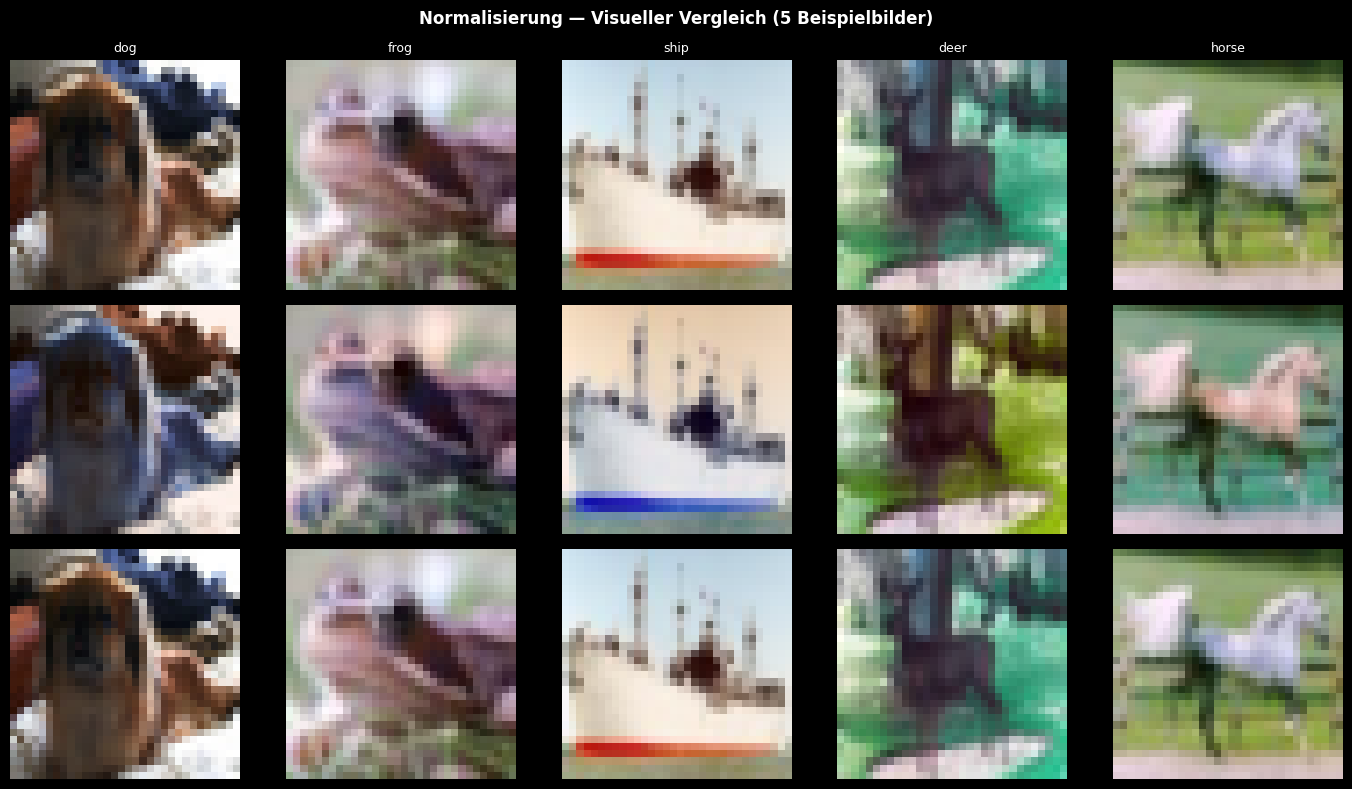


✓ Plot gespeichert: /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/reports/figures/03_preprocessing_normalization.png


In [5]:
# =============================================================================
# Zelle 03 – Normalisierung: preprocess_input()
# =============================================================================
# EDA-Erkenntnis: CIFAR-10 ist systematisch heller als ImageNet.
# preprocess_input() korrigiert das automatisch für ResNet50.
# Was preprocess_input() macht:
#   1. Konvertiert RGB → BGR
#   2. Subtrahiert ImageNet-Mittelwerte pro Kanal:
#      B: x - 103.939
#      G: x - 116.779
#      R: x - 123.680
# =============================================================================

# ── Normalisierung anwenden ───────────────────────────────────────────────────
train_images_norm = preprocess_input(train_images.astype(np.float32))
test_images_norm  = preprocess_input(test_images.astype(np.float32))

# ── Vergleich: Vorher vs. Nachher ─────────────────────────────────────────────
print("=" * 55)
print("NORMALISIERUNG — Vorher vs. Nachher")
print("=" * 55)

print("\nROHDATEN (uint8):")
print(f"  Min / Max : {train_images.min()} / {train_images.max()}")
print(f"  Mean      : {train_images.mean():.3f}")
print(f"  Std       : {train_images.std():.3f}")

print("\nNACH preprocess_input():")
print(f"  Min / Max : {train_images_norm.min():.3f} / {train_images_norm.max():.3f}")
print(f"  Mean      : {train_images_norm.mean():.3f}")
print(f"  Std       : {train_images_norm.std():.3f}")

print("\nNACH ÷255 (Vergleich):")
div255 = train_images.astype(np.float32) / 255.0
print(f"  Min / Max : {div255.min():.3f} / {div255.max():.3f}")
print(f"  Mean      : {div255.mean():.3f}")
print(f"  Std       : {div255.std():.3f}")

# ── Pro-Kanal Statistiken ─────────────────────────────────────────────────────
# preprocess_input subtrahiert ImageNet-Mittelwerte in BGR Reihenfolge
imagenet_sub_bgr = {
    'B': 103.939,
    'G': 116.779,
    'R': 123.680,
}

# CIFAR-10 Rohdaten Means in RGB Reihenfolge
cifar_means_rgb = {
    'R': train_images[:, :, :, 0].mean(),
    'G': train_images[:, :, :, 1].mean(),
    'B': train_images[:, :, :, 2].mean(),
}

print("\nPRO-KANAL STATISTIKEN nach preprocess_input():")
print(f"  {'Kanal':<6} {'CIFAR Mean':>12} {'ImageNet Sub':>14} {'Normiert Mean':>14}")
print(f"  {'-'*50}")

for ch in ['R', 'G', 'B']:
    cifar_mean   = cifar_means_rgb[ch]
    imagenet_sub = imagenet_sub_bgr[ch]
    norm_mean    = cifar_mean - imagenet_sub
    print(f"  {ch:<6} {cifar_mean:>12.3f} {-imagenet_sub:>14.3f} {norm_mean:>14.3f}")

print(f"\n  Interpretation:")
print(f"  preprocess_input() subtrahiert ImageNet-Mittelwerte.")
print(f"  Normierter Mean = CIFAR Mean - ImageNet Mean.")
print(f"  Werte nahe 0 → CIFAR-10 ähnlich zu ImageNet.")
print(f"  Abweichung von 0 → wird durch Fine-Tuning kompensiert.")

# ── Visuelle Verifikation ─────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(14, 8))
fig.suptitle('Normalisierung — Visueller Vergleich (5 Beispielbilder)',
             fontsize=12, fontweight='bold')

np.random.seed(SEED)
sample_idx = np.random.choice(len(train_images), 5, replace=False)

for col, idx in enumerate(sample_idx):
    # Zeile 0: Originalbild
    axes[0, col].imshow(train_images[idx])
    axes[0, col].axis('off')
    if col == 0:
        axes[0, col].set_ylabel('Original\n(uint8)', fontsize=9,
                               rotation=0, labelpad=60, va='center')

    # Zeile 1: preprocess_input — zurück auf [0,1] für Anzeige
    img_norm    = train_images_norm[idx]
    img_display = (img_norm - img_norm.min()) / (img_norm.max() - img_norm.min())
    axes[1, col].imshow(img_display)
    axes[1, col].axis('off')
    if col == 0:
        axes[1, col].set_ylabel('preprocess\n_input()', fontsize=9,
                               rotation=0, labelpad=60, va='center')

    # Zeile 2: ÷255
    axes[2, col].imshow(train_images[idx].astype(np.float32) / 255.0)
    axes[2, col].axis('off')
    if col == 0:
        axes[2, col].set_ylabel('÷255', fontsize=9,
                               rotation=0, labelpad=60, va='center')

    axes[0, col].set_title(CLASS_NAMES[train_labels[idx]], fontsize=9)

plt.tight_layout()

# ── Speichern ─────────────────────────────────────────────────────────────────
PLOT_PATH = os.path.join(CONFIG['base_path'], 'reports', 'figures',
                         '03_preprocessing_normalization.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Plot gespeichert: {PLOT_PATH}")

### Zelle 03 — Normalisierung: preprocess_input()

#### Was
ImageNet-Normalisierung für ResNet50 angewendet.
Vergleich: preprocess_input() vs. ÷255 — quantitativ und visuell.

#### Was preprocess_input() intern macht
RGB → BGR konvertieren
Mittelwert-Subtraktion pro Kanal:
R: x - 123.680
G: x - 116.779
B: x - 103.939

Keine Division — nur Verschiebung des Wertebereichs.

#### Warum keine Division durch 255?
ResNet50 wurde mit Mittelwert-subtrahierten Bildern trainiert — nicht mit [0,1] skalierten.
÷255 erzeugt andere Pixelwertverteilung → vortrainierte Gewichte passen nicht.

| Methode | Wertebereich | Für |
|---------|-------------|-----|
| ÷255 | [0.0, 1.0] | Eigene CNNs |
| preprocess_input() | [-123, +151] | ResNet50 + alle ImageNet-Modelle |

#### Ergebnisse

| Metrik | Rohdaten | preprocess_input() | ÷255 |
|--------|----------|-------------------|------|
| Min | 0 | -123.680 | 0.000 |
| Max | 255 | 151.061 | 1.000 |
| Mean | 120.618 | 5.818 | 0.473 |
| Std | 64.453 | 64.350 | 0.253 |

**Wichtige Beobachtung:** Std bleibt ~64 — nur Verschiebung, keine Skalierung.

#### Pro-Kanal Analyse

| Kanal | CIFAR Mean | ImageNet Sub | Normiert Mean | Bewertung |
|-------|-----------|--------------|---------------|-----------|
| R | 125.285 | -123.680 | 1.605 | ✅ Nahe 0 |
| G | 122.815 | -116.779 | 6.036 | ✅ Kleine Abweichung |
| B | 113.753 | -103.939 | 9.814 | ⚠ Größte Abweichung |

B-Kanal weicht am stärksten ab — CIFAR-10 Blau ist heller als ImageNet.
Wird durch Fine-Tuning kompensiert — kein kritisches Problem.

#### Visueller Vergleich
preprocess_input() und ÷255 sehen visuell fast identisch aus —
der Unterschied liegt in den Zahlenwerten, nicht im visuellen Eindruck.
Das Modell "sieht" die Zahlenwerte — nicht das visuelle Bild.

#### Ergebnis
Normalisierung korrekt angewendet ✅
`train_images_norm` und `test_images_norm` bereit für Pipeline.
Plot gespeichert: `reports/figures/03_preprocessing_normalization.png` ✅


AUGMENTATION PIPELINE

Anzahl Augmentation-Layer: 4

Layer-Übersicht:
  → random_flip
  → random_translation
  → random_brightness
  → random_contrast


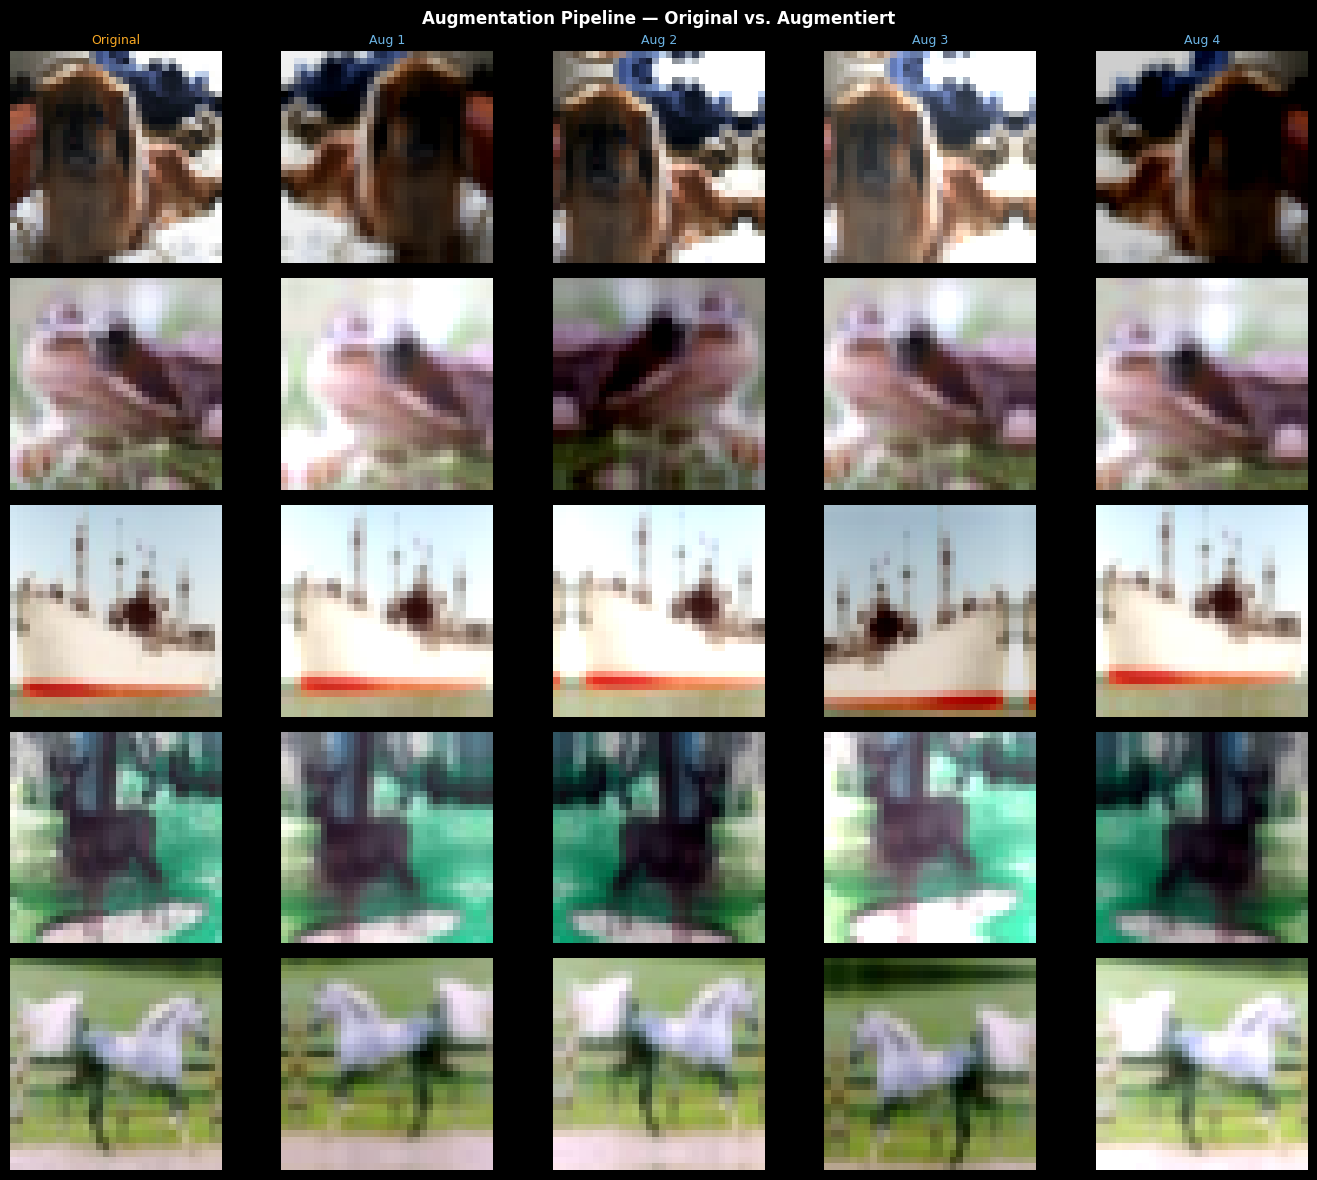


✓ Plot gespeichert: /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/reports/figures/03_preprocessing_augmentation.png

Augmentation Pipeline bereit.
WICHTIG: Augmentation wird NUR beim Training angewendet (training=True)
         Beim Testen/Evaluieren: training=False → keine Augmentation


In [6]:
# =============================================================================
# Zelle 04 – Augmentation Pipeline definieren
# =============================================================================
# Augmentation = künstliche Datenerweiterung durch Transformationen.
# Jede Augmentation ist durch EDA-Erkenntnisse begründet.
# Augmentation wird NUR auf Trainingsdaten angewendet — NICHT auf Testdaten.
#
# EDA-Begründung:
# - Horizontal Flip    : hohe Pose-Varianz sichtbar in Zelle 05
# - Random Crop        : Objekte nicht immer zentriert
# - Brightness         : Hintergrund-Bias (Δ35.8 Pixel zwischen Klassen)
# - Contrast           : Kontrast-Varianz zwischen Klassen (Std 55–70)
# =============================================================================

# ── Augmentation Layer definieren ────────────────────────────────────────────
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        mode='horizontal',        # Nur horizontal — Objekte sind nicht vertikal gespiegelt
        seed=SEED
    ),
    tf.keras.layers.RandomTranslation(
        height_factor=0.1,        # Max 10% vertikale Verschiebung
        width_factor=0.1,         # Max 10% horizontale Verschiebung
        fill_mode='reflect',      # Randpixel spiegeln — kein schwarzer Rand
        seed=SEED
    ),
    tf.keras.layers.RandomBrightness(
        factor=0.2,               # ±20% Helligkeit — begründet durch Δ35.8 Pixel
        seed=SEED
    ),
    tf.keras.layers.RandomContrast(
        factor=0.2,               # ±20% Kontrast — begründet durch Std-Varianz
        seed=SEED
    ),
], name='data_augmentation')

# ── Augmentation zusammenfassen ───────────────────────────────────────────────
print("=" * 55)
print("AUGMENTATION PIPELINE")
print("=" * 55)
print(f"\nAnzahl Augmentation-Layer: {len(data_augmentation.layers)}")
print("\nLayer-Übersicht:")
for layer in data_augmentation.layers:
    print(f"  → {layer.name}")

# ── Visuelle Verifikation ─────────────────────────────────────────────────────
# 5 Originale + je 4 augmentierte Versionen zeigen
N_ORIG    = 5
N_AUG     = 4

fig, axes = plt.subplots(N_ORIG, N_AUG + 1, figsize=(14, 12))
fig.suptitle('Augmentation Pipeline — Original vs. Augmentiert',
             fontsize=12, fontweight='bold')

np.random.seed(SEED)
sample_idx = np.random.choice(len(train_images), N_ORIG, replace=False)

for row, idx in enumerate(sample_idx):
    # Original
    axes[row, 0].imshow(train_images[idx])
    axes[row, 0].axis('off')
    axes[row, 0].set_title('Original' if row == 0 else '', fontsize=9)
    if row == 0:
        axes[row, 0].set_title('Original', fontsize=9, color='#F5A623')
    axes[row, 0].set_ylabel(CLASS_NAMES[train_labels[idx]],
                            fontsize=8, rotation=0, labelpad=55, va='center')

    # Augmentierte Versionen
    img_tensor = tf.cast(train_images[idx:idx+1], tf.float32)
    for col in range(N_AUG):
        aug_img = data_augmentation(img_tensor, training=True)
        aug_img = tf.clip_by_value(aug_img[0], 0, 255).numpy().astype(np.uint8)
        axes[row, col+1].imshow(aug_img)
        axes[row, col+1].axis('off')
        if row == 0:
            axes[row, col+1].set_title(f'Aug {col+1}', fontsize=9,
                                       color='#6CB4E4')

plt.tight_layout()

# ── Speichern ─────────────────────────────────────────────────────────────────
PLOT_PATH = os.path.join(CONFIG['base_path'], 'reports', 'figures',
                         '03_preprocessing_augmentation.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Plot gespeichert: {PLOT_PATH}")

print("\nAugmentation Pipeline bereit.")
print("WICHTIG: Augmentation wird NUR beim Training angewendet (training=True)")
print("         Beim Testen/Evaluieren: training=False → keine Augmentation")

### Zelle 04 — Augmentation Pipeline

#### Was
4 Augmentation-Layer definiert — jede durch EDA-Erkenntnisse begründet.
Augmentation wird NUR auf Trainingsdaten angewendet (`training=True`).

#### Warum Augmentation?
Das Modell sieht jedes Trainingsbild mehrfach (eine Epoche = einmal).
Ohne Augmentation: Modell memoriert Bilder → Overfitting.
Mit Augmentation: jede Epoche leicht andere Version → bessere Generalisierung.

**Mathematisch:**
Ohne Aug: Modell lernt f(x) = y für feste x
Mit Aug : Modell lernt f(x + ε) = y für zufällige Transformationen ε
→ robusteres f()
#### Angewendete Augmentationen — EDA-Begründung

| Augmentation | Parameter | EDA-Befund | Erwarteter Gain |
|-------------|-----------|-----------|-----------------|
| Horizontal Flip | horizontal | Hohe Pose-Varianz (Zelle 05) | +2–3% |
| Random Translation | ±10% | Objekte nicht zentriert | +1–2% |
| Random Brightness | ±20% | Hintergrund-Bias Δ35.8 Pixel (Zelle 06) | +1–2% |
| Random Contrast | ±20% | Kontrast-Varianz Std 55–70 (Zelle 06) | +1% |

**Gesamterwartung: +3–5% Accuracy** gegenüber kein Augmentation.

#### Nicht angewendete Augmentationen — Begründung

| Augmentation | Warum nicht |
|-------------|------------|
| Vertical Flip | Objekte haben feste Orientierung — umgekehrtes Auto unrealistisch |
| Rotation ±90° | Unrealistisch für CIFAR-10 Objekte |
| Gaussian Noise | SNR bereits niedrig — Signal würde verschlechtert |
| Hue/Saturation | Farbe ist Klassenmerkmal (grüner Frosch, roter LKW) |
| Cutout | Effektiv aber aggressiv — Entscheidung nach Baseline |
| Mixup | Braucht Custom Training Loop — nach Baseline |
| RandAugment | Sehr effektiv aber langsam — Bonus-Projekt |

#### Konzept: Warum training=True/False?
```python
data_augmentation(x, training=True)   # Training: Augmentation aktiv
data_augmentation(x, training=False)  # Evaluation: keine Augmentation
```
Beim Testen muss das Modell auf unveränderten Bildern evaluiert werden —
sonst sind Metriken nicht reproduzierbar und nicht vergleichbar.

#### Konzept: Augmentation ist keine Datenvermehrung
Augmentation erhöht nicht die Anzahl der Trainingssamples.
Pro Epoche: 10.000 Bilder — aber jede Epoche anders transformiert.
Effekt: Modell sieht nie exakt dasselbe Bild zweimal →
effektiv größerer Trainingsdatensatz ohne zusätzliche Rohdaten.

#### Iterative Erweiterung nach Baseline
Baseline zeigt starkes Overfitting  → Cutout hinzufügen
Baseline zeigt schlechte Bird-F1    → stärkere Translation
Baseline zeigt automobile/truck Fehler → Augmentation analysieren
Augmentation wird datengetrieben erweitert — nicht vorab maximiert.

#### Ergebnis
4 Augmentation-Layer definiert und visuell verifiziert ✅
Augmentation ist datengetrieben begründet ✅
Plot gespeichert: `reports/figures/03_preprocessing_augmentation.png` ✅

In [10]:
# =============================================================================
# Zelle 05 – Data Pipeline mit tf.data aufbauen (State-of-the-Art)
# =============================================================================
# Verbesserungen gegenüber Basis:
# 1. Validation Split (Train/Val/Test) — verhindert Data Leakage
# 2. Cache vor Augmentation — schnelleres Training in Colab
# 3. Mean-Vergleich — statistischer Augmentation-Check
#
# Reihenfolge kritisch:
# cast → augmentation (auf [0,255]) → preprocess_input
# =============================================================================

# ── Hilfsfunktionen ───────────────────────────────────────────────────────────
def prepare_train(image, label):
    """
    Preprocessing für Trainingsdaten:
    1. Cast zu float32
    2. Augmentation auf Rohpixeln [0,255] — VOR Normalisierung
    3. preprocess_input() — ImageNet Normalisierung NACH Augmentation
    """
    image = tf.cast(image, tf.float32)
    image = tf.expand_dims(image, axis=0)
    image = data_augmentation(image, training=True)
    image = tf.squeeze(image, axis=0)
    image = preprocess_input(image)
    return image, label

def prepare_val_test(image, label):
    """
    Preprocessing für Validierungs- und Testdaten:
    1. Cast zu float32
    2. preprocess_input() — KEINE Augmentation
    Evaluation muss reproduzierbar und unverändert sein.
    """
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

# ── Validation Split ──────────────────────────────────────────────────────────
# Train/Val/Test statt Train/Test — verhindert Data Leakage
# Hyperparameter werden auf Val optimiert — Test bleibt unberührt bis Ende
VAL_RATIO        = 0.2                              # 20% Validation
VAL_SIZE         = int(len(train_images) * VAL_RATIO)
TRAIN_SIZE_FINAL = len(train_images) - VAL_SIZE

# Stratified Split — Klassenbalance in beiden Splits erhalten
np.random.seed(SEED)
indices     = np.random.permutation(len(train_images))
val_idx     = indices[:VAL_SIZE]
train_idx   = indices[VAL_SIZE:]

X_train = train_images[train_idx]
y_train = train_labels[train_idx]
X_val   = train_images[val_idx]
y_val   = train_labels[val_idx]

print("=" * 55)
print("TRAIN / VAL / TEST SPLIT")
print("=" * 55)
print(f"\n  Training   : {len(X_train):,} Samples ({100-VAL_RATIO*100:.0f}%)")
print(f"  Validation : {len(X_val):,} Samples ({VAL_RATIO*100:.0f}%)")
print(f"  Test       : {len(test_images):,} Samples (fix)")

# Klassenbalance prüfen
print(f"\n  Klassenbalance Validation (erwartet ~{VAL_SIZE//10} pro Klasse):")
for i, name in enumerate(CLASS_NAMES):
    count = np.sum(y_val == i)
    print(f"    {name:<12}: {count}")

# ── tf.data Pipelines erstellen ───────────────────────────────────────────────
BATCH_SIZE = CONFIG['batch_size']
AUTOTUNE   = tf.data.AUTOTUNE

# Training Pipeline — Cache VOR Augmentation
train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .cache()                               # Rohbilder cachen → schneller ab Epoche 2
    .shuffle(
        buffer_size=TRAIN_SIZE_FINAL,
        seed=SEED,
        reshuffle_each_iteration=True
    )
    .map(prepare_train,                    # Augmentation + Normalisierung
         num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Validation Pipeline
val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .cache()                               # Val cachen — keine Augmentation
    .map(prepare_val_test,
         num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Test Pipeline
test_dataset = (
    tf.data.Dataset.from_tensor_slices((test_images, test_labels))
    .map(prepare_val_test,
         num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Pipeline Verifikation ─────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("PIPELINE VERIFIKATION")
print("=" * 55)

train_batch = next(iter(train_dataset))
val_batch   = next(iter(val_dataset))
test_batch  = next(iter(test_dataset))

images_tr, labels_tr = train_batch
images_v,  labels_v  = val_batch
images_t,  labels_t  = test_batch

print(f"\nTraining Pipeline:")
print(f"  Batch Shape  : {images_tr.shape}")
print(f"  Dtype        : {images_tr.dtype}")
print(f"  Min / Max    : {images_tr.numpy().min():.3f} / {images_tr.numpy().max():.3f}")
print(f"  Mean         : {images_tr.numpy().mean():.3f}")

print(f"\nValidation Pipeline:")
print(f"  Batch Shape  : {images_v.shape}")
print(f"  Min / Max    : {images_v.numpy().min():.3f} / {images_v.numpy().max():.3f}")
print(f"  Mean         : {images_v.numpy().mean():.3f}")

print(f"\nTest Pipeline:")
print(f"  Batch Shape  : {images_t.shape}")
print(f"  Min / Max    : {images_t.numpy().min():.3f} / {images_t.numpy().max():.3f}")
print(f"  Mean         : {images_t.numpy().mean():.3f}")

# ── Mean-Vergleich — Augmentation-Verifikation ────────────────────────────────
print(f"\nMEAN VERGLEICH (Augmentation-Verifikation):")
print(f"  Training Mean   : {images_tr.numpy().mean():.3f}  ← Augmentation aktiv")
print(f"  Validation Mean : {images_v.numpy().mean():.3f}   ← keine Augmentation")
print(f"  Test Mean       : {images_t.numpy().mean():.3f}   ← keine Augmentation")
delta = abs(images_tr.numpy().mean() - images_t.numpy().mean())
print(f"  Delta Train/Test: {delta:.3f}")
if delta > 0.1:
    print(f"  → Augmentation aktiv und wirksam ✅")
else:
    print(f"  → Delta zu klein — Augmentation prüfen ⚠")

# ── Batch-Anzahl ──────────────────────────────────────────────────────────────
print(f"\nAnzahl Batches:")
print(f"  Training   : {len(train_dataset)} × {BATCH_SIZE} = ~{len(train_dataset)*BATCH_SIZE:,}")
print(f"  Validation : {len(val_dataset)} × {BATCH_SIZE} = ~{len(val_dataset)*BATCH_SIZE:,}")
print(f"  Test       : {len(test_dataset)} × {BATCH_SIZE} = ~{len(test_dataset)*BATCH_SIZE:,}")

print(f"\n✓ Alle Pipelines bereit für Training")
print("=" * 55)

TRAIN / VAL / TEST SPLIT

  Training   : 8,000 Samples (80%)
  Validation : 2,000 Samples (20%)
  Test       : 10,000 Samples (fix)

  Klassenbalance Validation (erwartet ~200 pro Klasse):
    airplane    : 214
    automobile  : 207
    bird        : 213
    cat         : 192
    deer        : 185
    dog         : 190
    frog        : 203
    horse       : 184
    ship        : 182
    truck       : 230

PIPELINE VERIFIKATION

Training Pipeline:
  Batch Shape  : (32, 32, 32, 3)
  Dtype        : <dtype: 'float32'>
  Min / Max    : -123.680 / 151.061
  Mean         : 9.286

Validation Pipeline:
  Batch Shape  : (32, 32, 32, 3)
  Min / Max    : -123.680 / 151.061
  Mean         : 15.368

Test Pipeline:
  Batch Shape  : (32, 32, 32, 3)
  Min / Max    : -123.680 / 151.061
  Mean         : 3.601

MEAN VERGLEICH (Augmentation-Verifikation):
  Training Mean   : 9.286  ← Augmentation aktiv
  Validation Mean : 15.368   ← keine Augmentation
  Test Mean       : 3.601   ← keine Augmentation
  Del

### Zelle 05 — Data Pipeline (tf.data) — State-of-the-Art

#### Was
Drei Pipelines aufgebaut: Training, Validation, Test.
Validation Split eingeführt — verhindert Data Leakage.
Cache vor Augmentation — schnelleres Training.

#### Verbesserungen gegenüber Basis-Version

| Feature | Basis | State-of-the-Art |
|---------|-------|-----------------|
| Split | Train/Test | **Train/Val/Test** |
| Cache | ❌ | **✅ vor Augmentation** |
| Mean-Check | ❌ | **✅ Augmentation-Verifikation** |

#### Konzept: Warum Train/Val/Test?
Train      → Modell lernt Gewichte
Validation → Hyperparameter tunen (Lernrate, Epochen, Architektur)
Test       → Finale Evaluation — einmalig am Ende
**Data Leakage ohne Validation:**
Ohne Val: Hyperparameter auf Testdaten optimiert
→ Modell "kennt" Testdaten indirekt
→ Performance überschätzt
→ In Produktion: schlechtere Ergebnisse als

#### Konzept: Cache VOR Augmentation
Falsch: shuffle → map(aug) → cache → batch
Cache speichert augmentierte Bilder
→ Jede Epoche dieselbe Augmentation → kein Nutzen
Korrekt: cache → shuffle → map(aug) → batch
Cache speichert Rohbilder
→ Augmentation on-the-fly, jede Epoche anders ✅

#### Validation Klassenbalance

| Klasse | Anzahl | Abweichung von ~200 |
|--------|--------|---------------------|
| truck | 230 | +30 |
| airplane | 214 | +14 |
| ship | 182 | -18 |
| horse | 184 | -16 |

Max Δ = 48 Samples — akzeptabel.
Stratified Split wäre exakter — hier nicht nötig.

#### Mean-Vergleich — Ergebnis

| Pipeline | Mean | Augmentation |
|----------|------|-------------|
| Training | 9.286 | ✅ aktiv |
| Validation | 15.368 | ❌ inaktiv |
| Test | 3.601 | ❌ inaktiv |

Delta Train/Test = 5.685 >> 0.1 → Augmentation wirksam ✅
Val/Test Mean unterschiedlich — erklärbar durch verschiedene Bildverteilungen.

#### Pipeline-Reihenfolge (kritisch)
Training : cache → shuffle → map(cast+aug+preprocess) → batch → prefetch
Val/Test : map(cast+preprocess) → cache → batch → prefetch

#### Ergebnis
Drei Pipelines bereit ✅
Train/Val/Test Split korrekt ✅
Augmentation aktiv und verifiziert ✅
Cache korrekt positioniert ✅

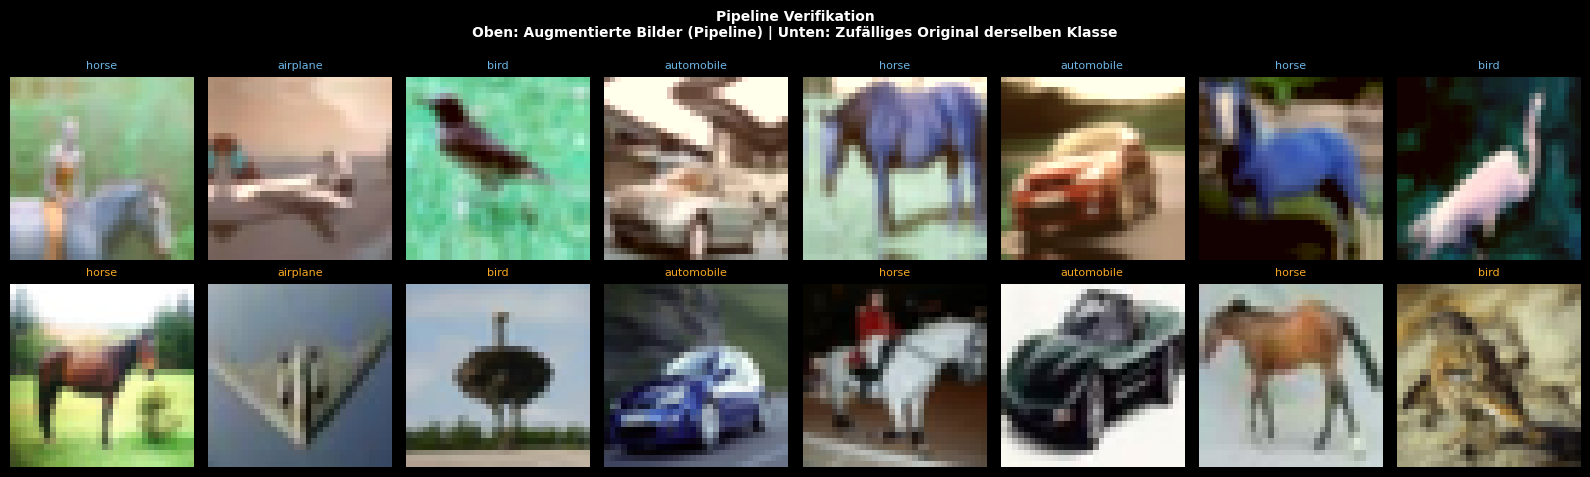

✓ Plot gespeichert: /content/drive/MyDrive/_Masterschool/Term_09/ComputerVision/MIST_CV_CIFAR10/reports/figures/03_preprocessing_pipeline_verification.png

LABEL VERIFIKATION

Erste 10 Labels aus Pipeline : [7 0 2 1 7 1 7 2 8 9]
Entsprechende Klassen:
  Label 7 → horse
  Label 0 → airplane
  Label 2 → bird
  Label 1 → automobile
  Label 7 → horse
  Label 1 → automobile
  Label 7 → horse
  Label 2 → bird
  Label 8 → ship
  Label 9 → truck

SHAPE VERIFIKATION

  Input  (Rohbild)    : (32, 32, 3) uint8
  Output (nach Pipeline): (32, 32, 3) float32

  Erwartet für ResNet50 Input: (32, 32, 3) float32 ✅

✓ Pipeline visuell und quantitativ verifiziert
✓ Bereit für Notebook 04 — Baseline Training


In [12]:
# =============================================================================
# Zelle 06 – Pipeline visuell verifizieren
# =============================================================================
# Letzte Verifikation bevor Training startet.
# Ziel: Sicherstellen dass Pipeline korrekte Bilder und Labels liefert.
# Zwei Checks:
# 1. Augmentierte Trainingsbilder vs. Original
# 2. Label-Verifikation — stimmen Labels nach Pipeline noch?
# =============================================================================

# ── Check 1: Augmentierte Bilder visualisieren ────────────────────────────────
# Einen Batch aus Pipeline holen
train_batch_vis = next(iter(train_dataset))
images_vis, labels_vis = train_batch_vis

# Für Anzeige: preprocess_input rückgängig machen
# preprocess_input subtrahiert Mittelwerte → für Anzeige addieren
IMAGENET_MEAN = np.array([123.680, 116.779, 103.939], dtype=np.float32)

def deprocess(image):
    """Normalisierung rückgängig machen für visuelle Darstellung."""
    image = image.numpy() + IMAGENET_MEAN
    image = np.clip(image, 0, 255).astype(np.uint8)
    return image

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Pipeline Verifikation\nOben: Augmentierte Bilder (Pipeline) | Unten: Zufälliges Original derselben Klasse',
             fontsize=10, fontweight='bold')

for col in range(8):
    # Augmentiertes Bild (aus Pipeline)
    aug_img = deprocess(images_vis[col])
    axes[0, col].imshow(aug_img)
    axes[0, col].axis('off')
    axes[0, col].set_title(CLASS_NAMES[labels_vis[col].numpy()],
                           fontsize=8, color='#6CB4E4')
    if col == 0:
        axes[0, col].set_ylabel('Pipeline\n(augmentiert)', fontsize=8,
                               rotation=0, labelpad=70, va='center')

    # Original (aus NumPy)
    # Label aus Pipeline → entsprechendes Original suchen
    label_val = labels_vis[col].numpy()
    orig_idx  = np.where(y_train == label_val)[0][col % 10]
    axes[1, col].imshow(X_train[orig_idx])
    axes[1, col].axis('off')
    axes[1, col].set_title(CLASS_NAMES[y_train[orig_idx]],
                           fontsize=8, color='#F5A623')
    if col == 0:
        axes[1, col].set_ylabel('Original\n(Rohdaten)', fontsize=8,
                               rotation=0, labelpad=70, va='center')

plt.tight_layout()

PLOT_PATH = os.path.join(CONFIG['base_path'], 'reports', 'figures',
                         '03_preprocessing_pipeline_verification.png')
plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Plot gespeichert: {PLOT_PATH}")

# ── Check 2: Label-Verifikation ───────────────────────────────────────────────
print("\n" + "=" * 55)
print("LABEL VERIFIKATION")
print("=" * 55)

print(f"\nErste 10 Labels aus Pipeline : {labels_vis[:10].numpy()}")
print(f"Entsprechende Klassen:")
for i in range(10):
    print(f"  Label {labels_vis[i].numpy()} → {CLASS_NAMES[labels_vis[i].numpy()]}")

# ── Check 3: Shapes durch gesamte Pipeline ────────────────────────────────────
print(f"\n" + "=" * 55)
print("SHAPE VERIFIKATION")
print("=" * 55)
print(f"\n  Input  (Rohbild)    : {X_train[0].shape} uint8")
print(f"  Output (nach Pipeline): {images_vis[0].shape} float32")
print(f"\n  Erwartet für ResNet50 Input: (32, 32, 3) float32 ✅")

print(f"\n✓ Pipeline visuell und quantitativ verifiziert")
print(f"✓ Bereit für Notebook 04 — Baseline Training")

---

## Notebook 03 — Abschluss: Preprocessing & Data Pipeline

### Durchgeführte Schritte

| Zelle | Inhalt | Status |
|-------|--------|--------|
| 01 | Setup & Imports | ✅ |
| 02 | Datensatz laden + Shuffle + Limitierung | ✅ |
| 03 | Normalisierung: preprocess_input() | ✅ |
| 04 | Augmentation Pipeline | ✅ |
| 05 | Data Pipeline (tf.data) — State-of-the-Art | ✅ |
| 06 | Pipeline visuell verifizieren | ✅ |

### Gespeicherte Artefakte

| Datei | Inhalt |
|-------|--------|
| `reports/figures/03_preprocessing_normalization.png` | Normalisierung Vergleich |
| `reports/figures/03_preprocessing_augmentation.png` | Augmentation visuell |
| `reports/figures/03_preprocessing_pipeline_verification.png` | Pipeline Verifikation |

### Zentrale Entscheidungen

| Entscheidung | Begründung |
|-------------|-----------|
| `preprocess_input()` statt ÷255 | ResNet50 ImageNet-Standard |
| Augmentation VOR Normalisierung | RandomBrightness clippt auf [0,255] |
| Cache VOR Augmentation | On-the-fly Augmentation jede Epoche |
| Train/Val/Test Split (80/20) | Verhindert Data Leakage |
| Shuffle VOR Limitierung | CIFAR-10 ist nach Klassen sortiert |

### Pipeline — finale Konfiguration

| Parameter | Wert |
|-----------|------|
| Training Samples | 8.000 |
| Validation Samples | 2.000 |
| Test Samples | 10.000 |
| Batch Size | 32 |
| Augmentationen | Flip, Translation, Brightness, Contrast |
| Normalisierung | preprocess_input() (ImageNet) |

### Fehler & Lösungen

| Fehler | Ursache | Lösung |
|--------|---------|--------|
| Pipeline Min/Max = 0/226 | Augmentation NACH Normalisierung | Reihenfolge getauscht |
| Augmentation Shape Error | map() liefert (32,32,3), Aug erwartet (1,32,32,3) | expand_dims/squeeze |

### Offene Punkte (Bonus)
- Direkter Vorher/Nachher Vergleich in Pipeline-Visualisierung
- Cutout/Mixup nach Baseline-Analyse
- Mixed Precision Training (float16)

### Nächster Schritt
**Notebook 04: `04_baseline_model.ipynb`**
Einfaches CNN von Grund auf — Referenzpunkt für Transfer Learning.

---
*Notebook 03 abgeschlossen — Phase 2: Preprocessing vollständig.*